# Predictive Maintenance — EDA & Preprocessing
**Dataset:** Predictive Maintenance Dataset (AI4I 2020)
**Target:** `Reason of Failure` — multiclass (7 classes: No Failure, TWF, HDF, PWF, OSF, RNF, Multiple Failures)

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler, SMOTE
from sklearn.preprocessing import StandardScaler
import joblib

RANDOM_STATE = 42
plt.rcParams["figure.figsize"] = (8, 5)
sns.set_style("whitegrid")

## 2. Load Data

In [2]:
df = pd.read_csv("../data/raw/ai4i2020.csv")
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 3. Data Quality Checks

In [3]:
df.shape

(10000, 14)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

In [5]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [6]:
print("Missing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
 UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

Duplicate rows: 0


### 3.1 Building the Target — `Reason of Failure`
الداتا الخام فيها عمود `Machine failure` (فشل ولا لأ) وخمس أعمدة بتحدد **نوع** الفشل: `TWF`, `HDF`, `PWF`, `OSF`, `RNF`. مفيش عمود جاهز يقول سبب الفشل، فبنبنيه من الأعمدة الخمسة:
- لو كل الأعمدة صفر → `No Failure`
- لو عمود واحد بس = 1 → بناخد اسمه
- لو أكتر من عمود = 1 في نفس الوقت → `Multiple Failures`

كمان بنحول `Type` لأرقام مؤقتًا (1=L, 2=M, 3=H) عشان نقدر نستخدمها في الـ EDA، وهنرجع نعمل One-Hot Encoding صح ليها بعدين في قسم الـ Preprocessing.

In [7]:
failure_cols = ["TWF", "HDF", "PWF", "OSF", "RNF"]

def get_failure_reason(row):
    active = [c for c in failure_cols if row[c] == 1]
    if len(active) == 0:
        return "No Failure"
    if len(active) == 1:
        return active[0]
    return "Multiple Failures"

df["Reason of Failure"] = df.apply(get_failure_reason, axis=1)
df["Type"] = df["Type"].map({"L": 1, "M": 2, "H": 3})
df = df.drop(columns=["UDI", "Product ID", "Machine failure"] + failure_cols)

df["Reason of Failure"].value_counts()

Reason of Failure
No Failure           9652
HDF                   106
PWF                    80
OSF                    78
TWF                    42
Multiple Failures      24
RNF                    18
Name: count, dtype: int64

## 4. Exploratory Data Analysis

### 4.1 Target & Categorical Distribution

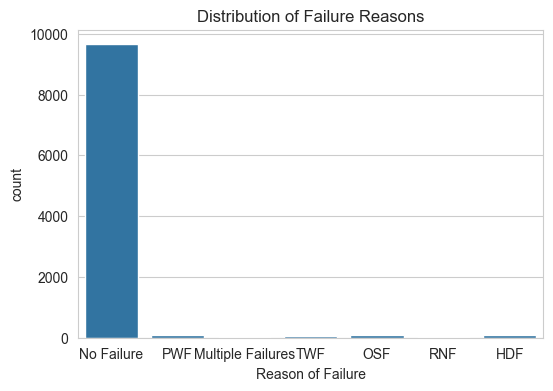

In [8]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Reason of Failure", data=df)
plt.title("Distribution of Failure Reasons")
plt.show()

**Insight:**
- Failures are a small slice of the data — the target is highly imbalanced.
- `No Failure` dominates, so raw accuracy alone won't say much about the rare failure types.

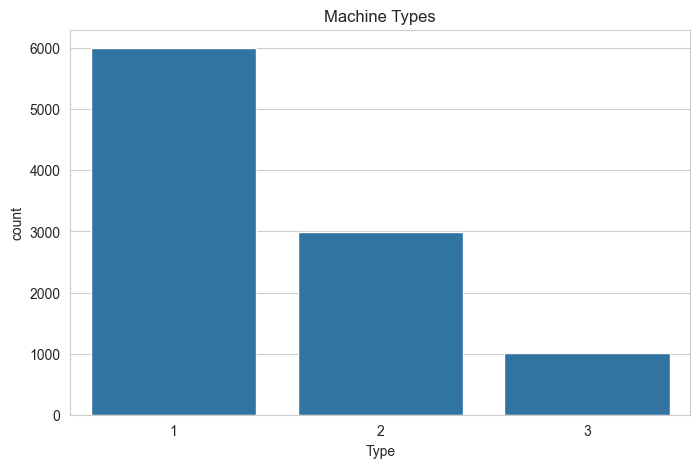

In [9]:
sns.countplot(x="Type", data=df)
plt.title("Machine Types")
plt.show()

**Insight:**
- Most machines are Type L, then M, with H the smallest group.

In [10]:
pd.crosstab(df["Type"], df["Reason of Failure"])

Reason of Failure,HDF,Multiple Failures,No Failure,OSF,PWF,RNF,TWF
Type,,,,,,,
1,68,17,5757,73,49,12,24
2,30,6,2916,4,27,2,12
3,8,1,979,1,4,4,6


### 4.2 Numeric Feature Distributions

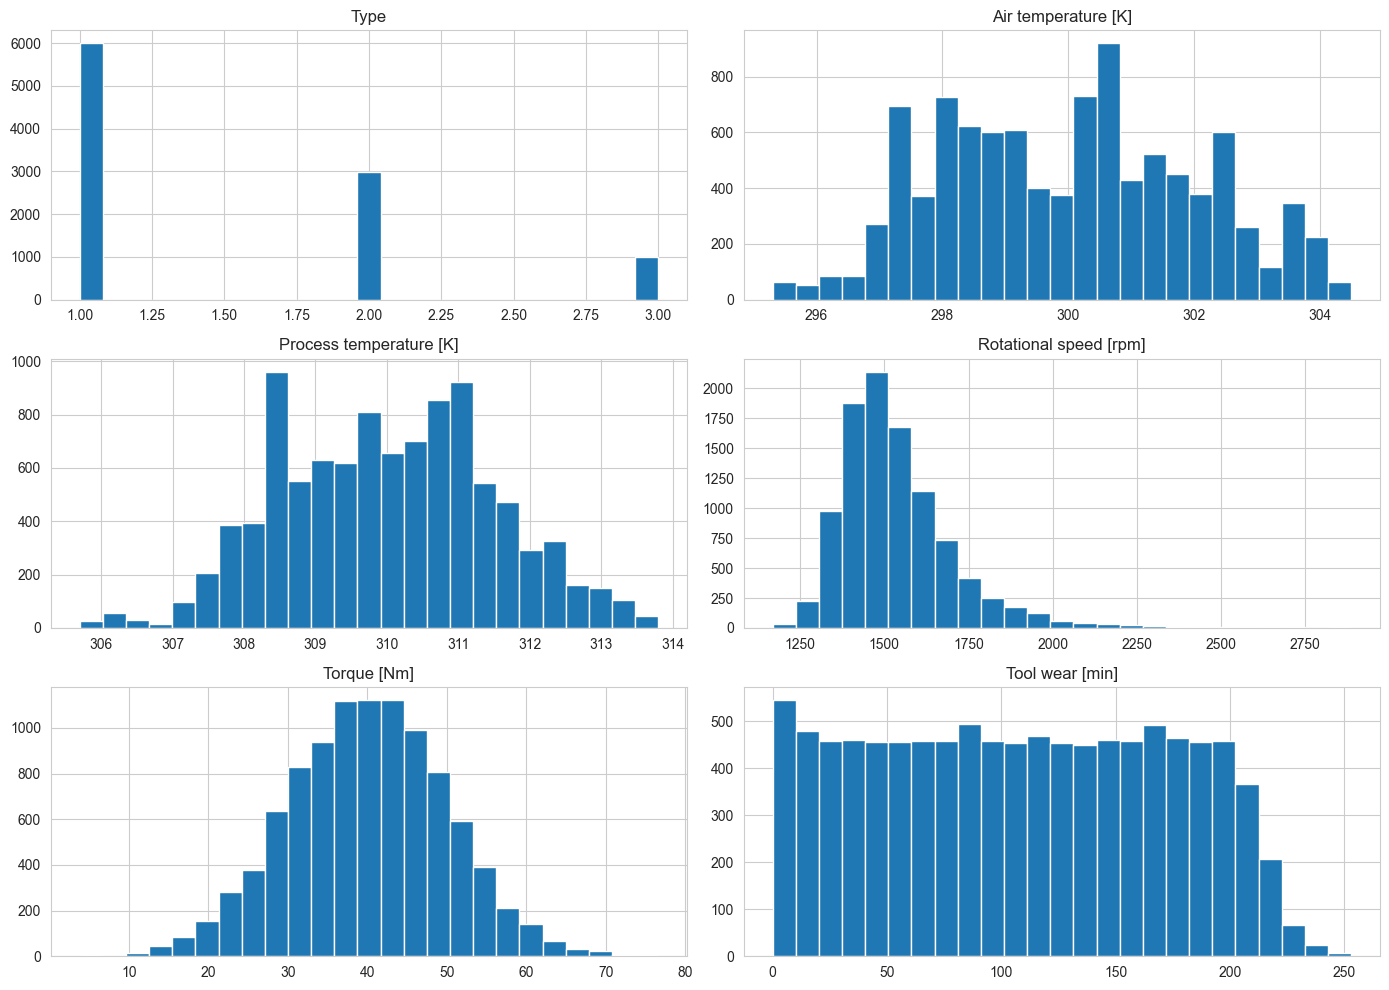

In [11]:
df.hist(figsize=(14, 10), bins=25)
plt.tight_layout()
plt.show()

**Insight:**
- Air and process temperature are roughly normally distributed.
- Rotational speed and torque are right-skewed with a longer tail.

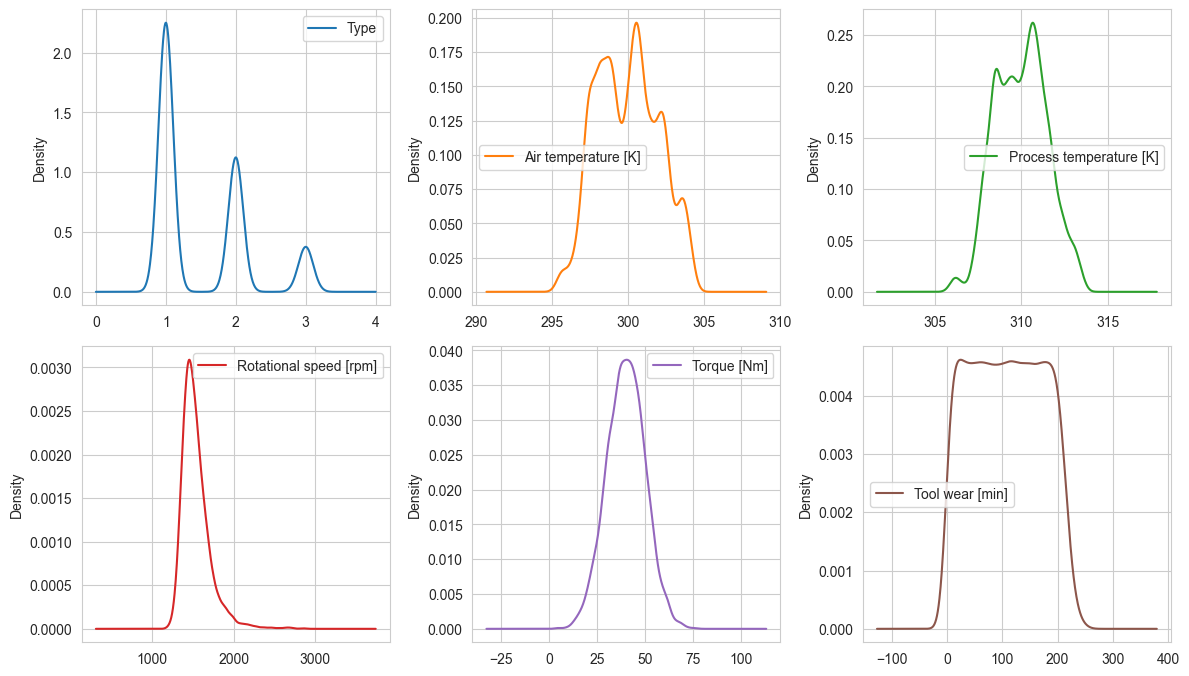

In [12]:
numeric = df.select_dtypes(include=np.number)
numeric.plot(kind="density", subplots=True, layout=(3, 3), figsize=(12, 10), sharex=False)
plt.tight_layout()
plt.show()

### 4.3 Boxplots per Feature (overall + by failure class)

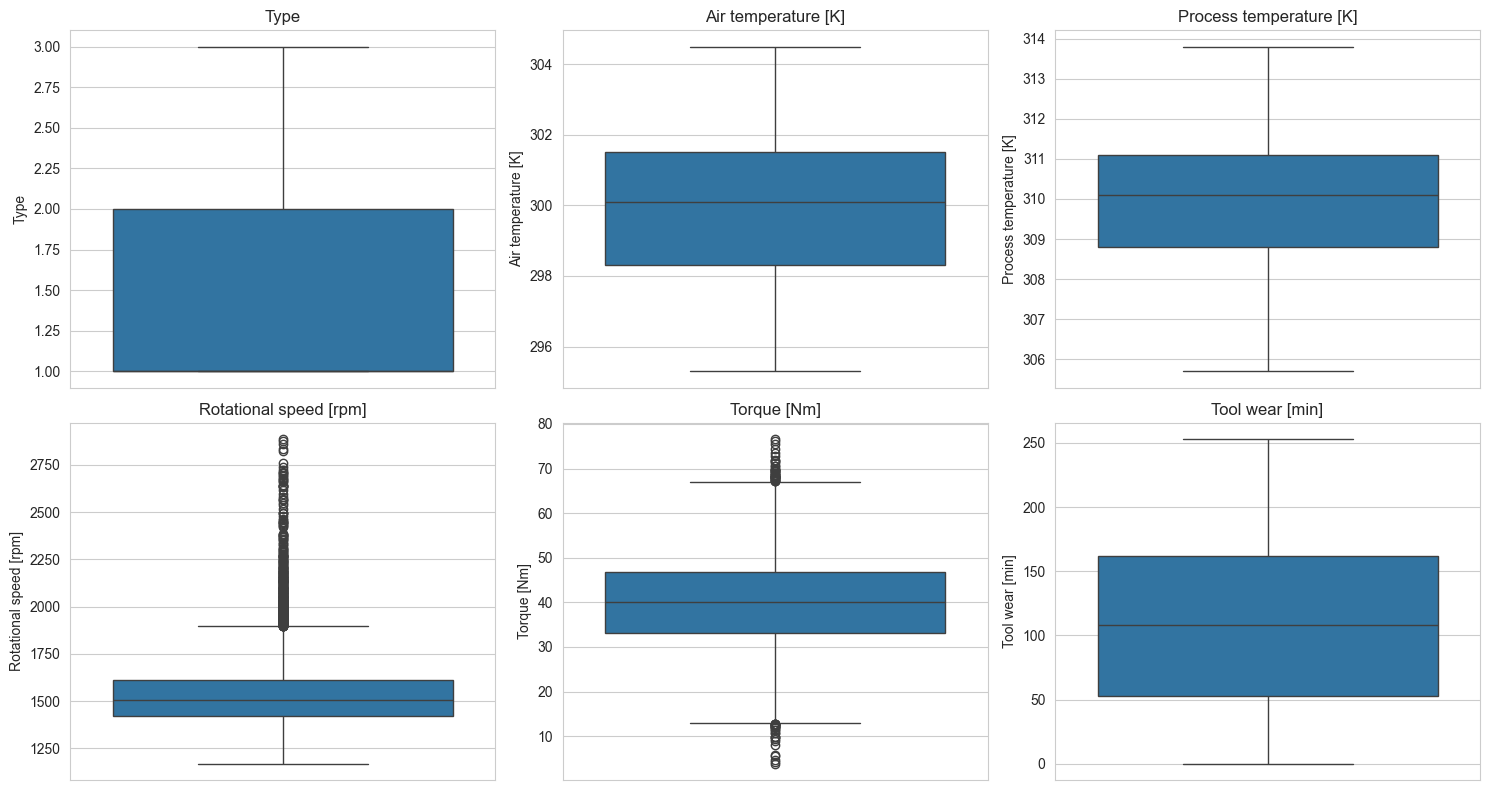

In [13]:
cols = df.columns[:-1]
plt.figure(figsize=(15, 8))
for i, col in enumerate(cols):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

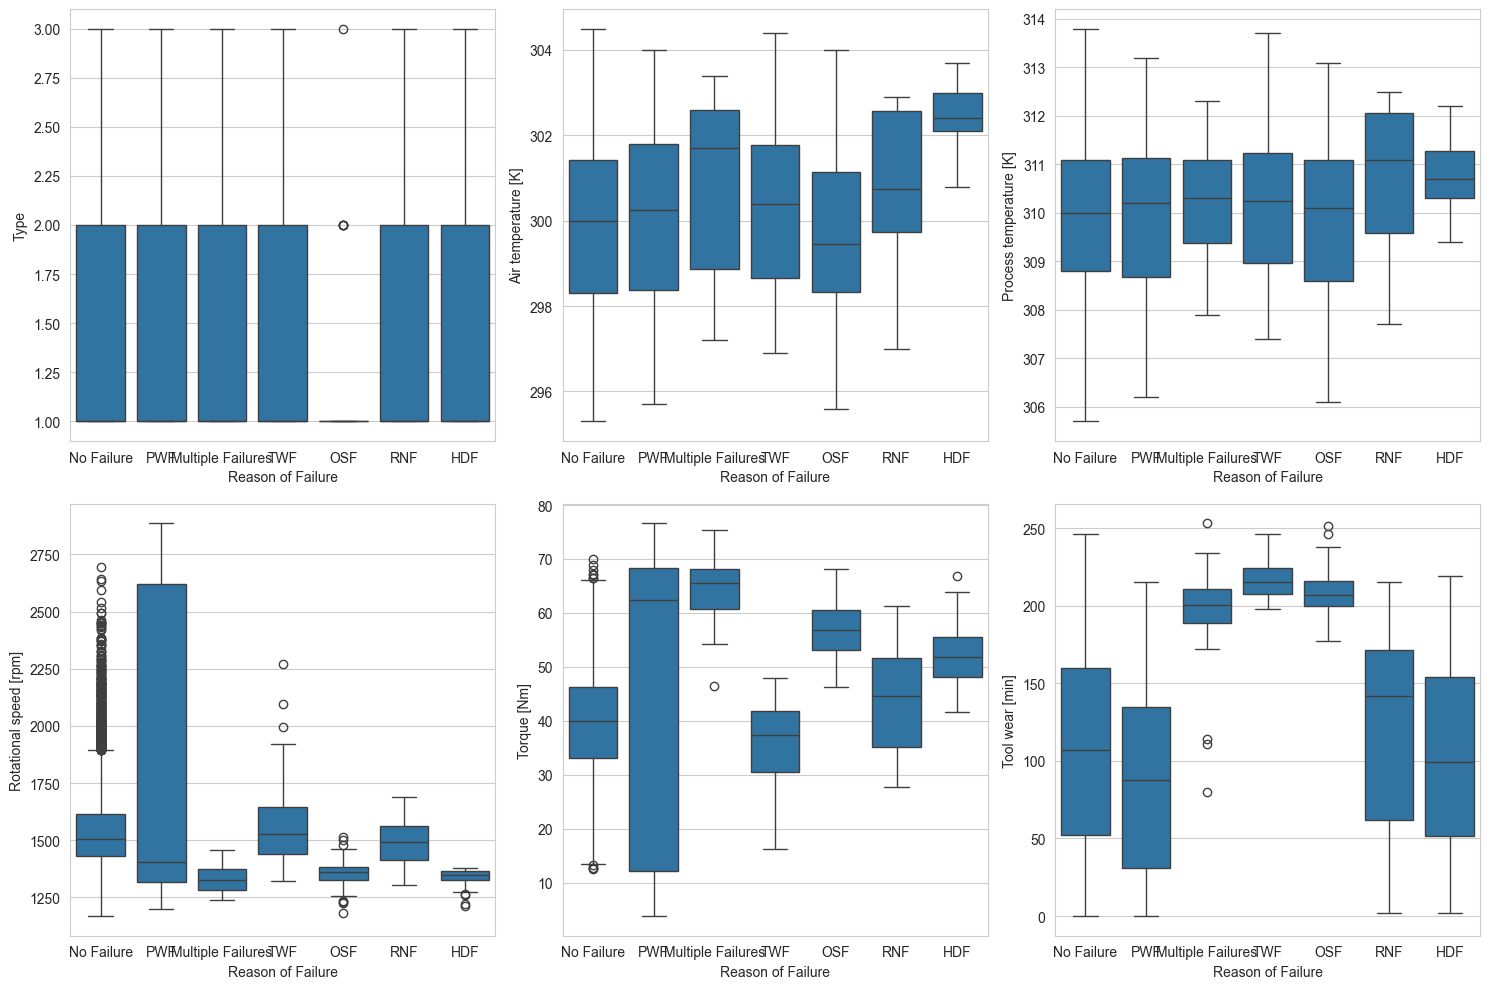

In [14]:
features = df.columns[:-1]
plt.figure(figsize=(15, 10))
for i, col in enumerate(features):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(x="Reason of Failure", y=col, data=df)
plt.tight_layout()
plt.show()

**Insight:**
- Torque and rotational speed shift noticeably for several failure classes vs. `No Failure`.
- Tool wear tends to run higher right before a failure, especially `TWF`.

### 4.4 Correlation & Relationships

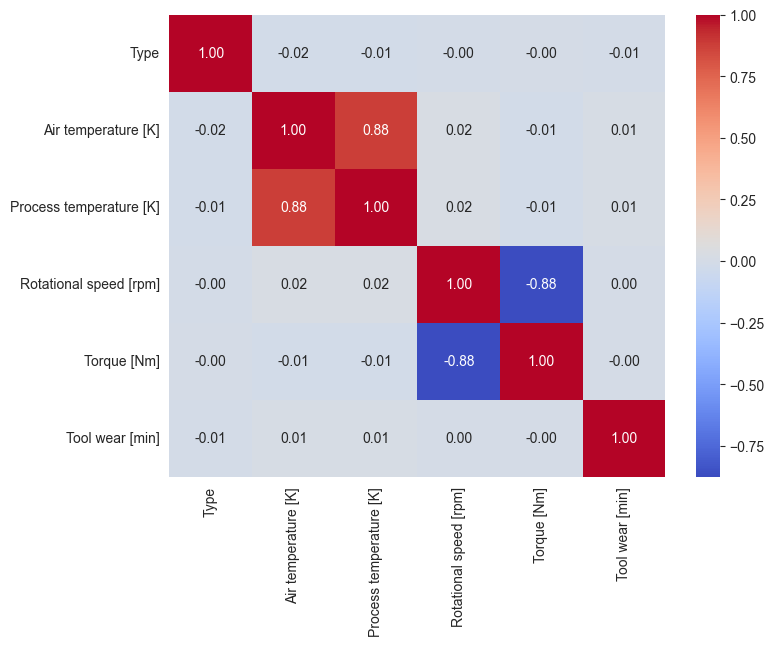

In [15]:
plt.figure(figsize=(8, 6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

**Insight:**
- Rotational speed and torque are strongly negatively correlated — consistent with power ≈ torque × speed.
- Air and process temperature move closely together.

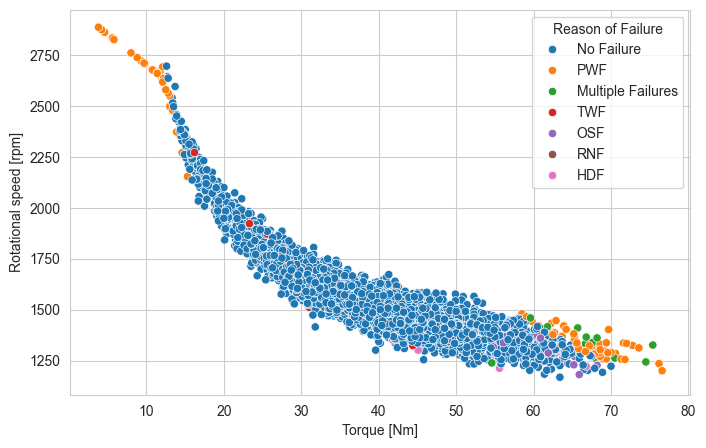

In [16]:
sns.scatterplot(x="Torque [Nm]", y="Rotational speed [rpm]", hue="Reason of Failure", data=df)
plt.show()

**Insight:**
- Failure points cluster at the extremes of the torque–speed relationship (very high torque at low speed, or the reverse).

### 4.5 Group Summaries by Failure Class

In [17]:
df.groupby("Reason of Failure").mean(numeric_only=True)

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
Reason of Failure,,,,,,
HDF,1.433962,302.560377,310.801887,1340.707547,52.363208,101.226415
Multiple Failures,1.333333,300.970833,310.220833,1334.958333,63.883333,192.708333
No Failure,1.504973,299.972855,309.994343,1540.324389,39.624316,106.678927
OSF,1.076923,299.867949,310.051282,1354.243590,56.878205,208.217949
PWF,1.437500,300.022500,309.961250,1843.237500,45.000000,87.625000
RNF,1.555556,300.766667,310.755556,1489.444444,43.522222,119.888889
TWF,1.571429,300.269048,310.128571,1583.238095,35.990476,216.214286


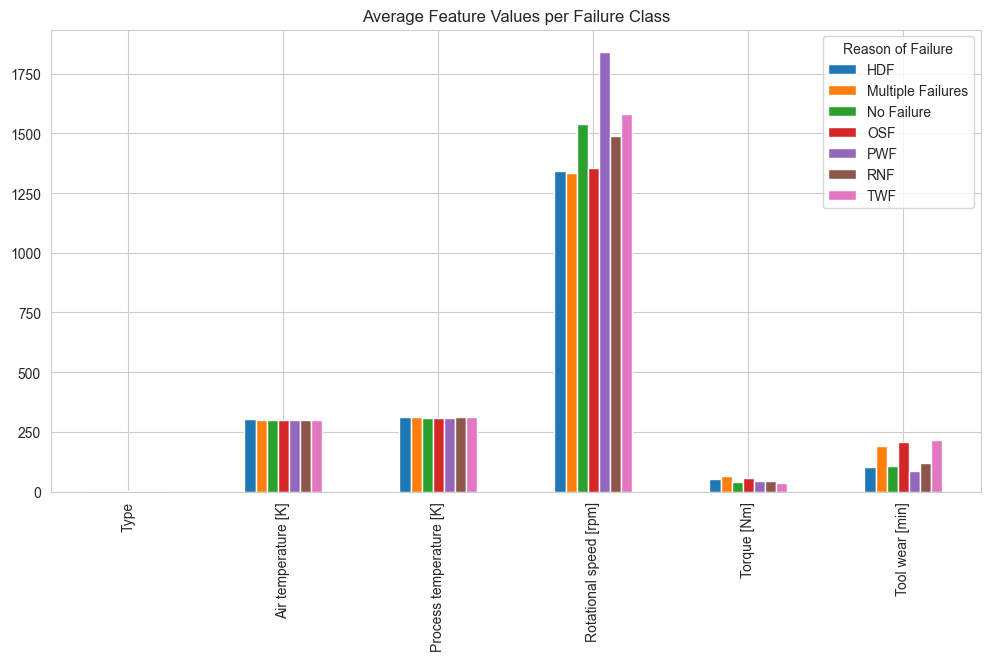

In [18]:
means = df.groupby("Reason of Failure").mean(numeric_only=True)
means.T.plot(kind="bar", figsize=(12, 6))
plt.title("Average Feature Values per Failure Class")
plt.show()

## 5. Outlier Analysis (Z-score)
تم فحص القيم الشاذة باستخدام Z-score. **لم يتم حذفها**: الفحص أظهر أن الـ outliers في `Rotational speed` و`Torque` مرتبطة فعليًا بحالات فشل حقيقية (خصوصًا في فئات معينة نادرة)، فهي تحمل إشارة مهمة عن الفئات النادرة وليست مجرد نويز.

In [19]:
numeric_cols = ["Air temperature [K]", "Process temperature [K]",
                "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]"]
z = (df[numeric_cols] - df[numeric_cols].mean()) / df[numeric_cols].std()
outlier_mask = (np.abs(z) > 3).any(axis=1)

print("Outliers |z|>3 per column:\n", (np.abs(z) > 3).sum())
print("\nFailure class distribution among outlier rows:\n",
      df.loc[outlier_mask, "Reason of Failure"].value_counts())

Outliers |z|>3 per column:
 Air temperature [K]          0
Process temperature [K]      0
Rotational speed [rpm]     164
Torque [Nm]                 25
Tool wear [min]              0
dtype: int64

Failure class distribution among outlier rows:
 Reason of Failure
No Failure           132
PWF                   41
Multiple Failures      3
TWF                    2
Name: count, dtype: int64


## 6. Preprocessing

### 6.1 Encoding
`Type` عمود Nominal (نوع الماكينة L/M/H) وليس Ordinal → One-Hot Encoding بدل الأرقام الخام.

In [20]:
df_encoded = pd.get_dummies(df, columns=["Type"], prefix="Type", drop_first=True)
bool_cols = df_encoded.select_dtypes(include="bool").columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)
df_encoded.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Reason of Failure,Type_2,Type_3
0,298.1,308.6,1551,42.8,0,No Failure,1,0
1,298.2,308.7,1408,46.3,3,No Failure,0,0
2,298.1,308.5,1498,49.4,5,No Failure,0,0
3,298.2,308.6,1433,39.5,7,No Failure,0,0
4,298.2,308.7,1408,40.0,9,No Failure,0,0


### 6.2 Scaling
الأعمدة الرقمية لسه بقيمها الحقيقية (كلفن، rpm، إلخ)، مش متسكيلة. هنعمل الـ Scaling بعد الـ Train/Test Split مباشرة (مش قبله) عشان نتجنب Data Leakage — الـ `scaler` هيتدرب على الـ train بس، وهنستخدمه يعدّل الـ test.

### 6.3 Train/Test Split
التقسيم يتم **قبل** أي معالجة لعدم التوازن لتفادي Data Leakage.

In [21]:
TARGET = "Reason of Failure"
X = df_encoded.drop(columns=[TARGET])
y = df_encoded[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("Train distribution:\n", y_train.value_counts())
print("\nTest distribution (real-world, untouched):\n", y_test.value_counts())

Train distribution:
 Reason of Failure
No Failure           7722
HDF                    85
PWF                    64
OSF                    62
TWF                    34
Multiple Failures      19
RNF                    14
Name: count, dtype: int64

Test distribution (real-world, untouched):
 Reason of Failure
No Failure           1930
HDF                    21
OSF                    16
PWF                    16
TWF                     8
Multiple Failures       5
RNF                     4
Name: count, dtype: int64


In [22]:
numeric_cols = ["Air temperature [K]", "Process temperature [K]",
                "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]"]

scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

X_train.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type_2,Type_3
2023,-0.652499,-1.015001,-0.521767,1.420045,-0.719316,0,0
3819,1.099697,0.471029,0.169978,-0.370404,-0.121186,0,0
9006,-1.353378,-1.420282,-0.673614,0.172766,1.232476,0,0
6343,0.098442,-0.136892,1.632204,-1.718271,-1.600770,0,0
6488,0.348756,-0.136892,-1.162897,1.440163,0.996372,0,0


أصغر فئة (على الأغلب `Multiple Failures`) عندها عدد عينات قليل جدًا في الـ train — أقل من أن يعمل معها SMOTE العادي مباشرة. تم استخدام معالجة على مرحلتين:
1. **RandomOverSampler**: رفع أصغر فئة لـ 10 عينات (بالتكرار) لتوفير جيران كافيين لـ SMOTE.
2. **SMOTE** (`k_neighbors=5`): موازنة كل الفئات لنفس عدد الفئة الأغلبية عبر توليد عينات صناعية.

In [24]:
print(y_train.value_counts().sort_values())

Reason of Failure
RNF                    14
Multiple Failures      19
TWF                    34
OSF                    62
PWF                    64
HDF                    85
No Failure           7722
Name: count, dtype: int64


In [25]:
class_counts = y_train.value_counts()

minority_classes = class_counts[class_counts < 50].index

sampling_dict = {
    cls: 50 for cls in minority_classes
}

stage_a = RandomOverSampler(
    sampling_strategy=sampling_dict,
    random_state=RANDOM_STATE
)

X_train_a, y_train_a = stage_a.fit_resample(
    X_train,
    y_train
)


stage_b = SMOTE(
    k_neighbors=5,
    random_state=RANDOM_STATE
)

X_train_bal, y_train_bal = stage_b.fit_resample(
    X_train_a,
    y_train_a
)

print(y_train_bal.value_counts())

Reason of Failure
No Failure           7722
HDF                  7722
Multiple Failures    7722
PWF                  7722
OSF                  7722
RNF                  7722
TWF                  7722
Name: count, dtype: int64


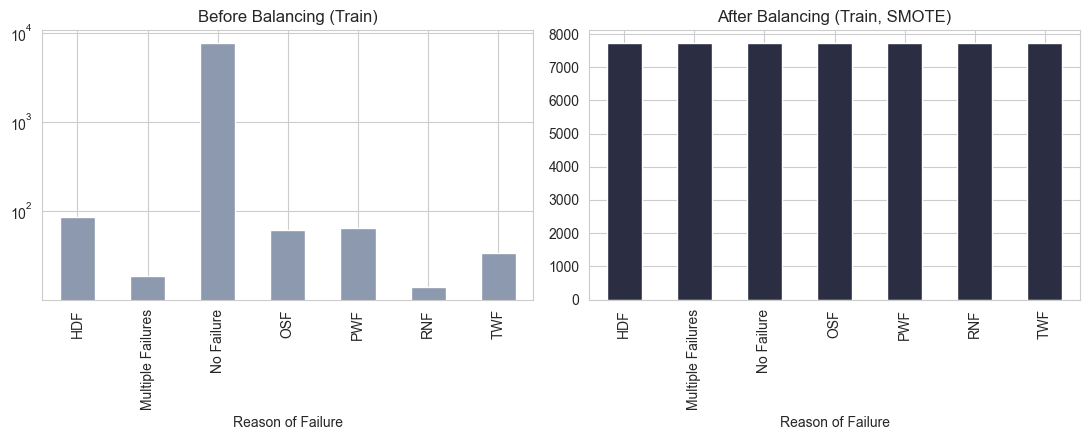

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
y_train.value_counts().sort_index().plot(kind="bar", ax=axes[0], color="#8d99ae")
axes[0].set_title("Before Balancing (Train)")
axes[0].set_yscale("log")
y_train_bal.value_counts().sort_index().plot(kind="bar", ax=axes[1], color="#2b2d42")
axes[1].set_title("After Balancing (Train, SMOTE)")
plt.tight_layout()
plt.show()

**Insight:**
- SMOTE brings every class up to the same size in the training set, but it doesn't add new real information for the rarest classes — worth remembering when judging their scores later.

> ⚠️ **تنبيه:** أصغر فئة عندها عدد قليل جدًا من العينات الحقيقية في كامل الداتا — أي عينات صناعية منها محدودة التنوع. يُفضّل الإشارة لهذا القيد عند تفسير أداء النموذج على هذه الفئة تحديدًا.

## 8. Save Processed Data

In [27]:
X_train_bal.to_csv("../data/processed/X_train_processed.csv", index=False)
y_train_bal.to_csv("../data/processed/y_train_processed.csv", index=False)
X_test.to_csv("../data/processed/X_test_processed.csv", index=False)
y_test.to_csv("../data/processed/y_test_processed.csv", index=False)

joblib.dump(scaler, "../models/scaler.pkl")

print("Saved processed data to data/processed/ and scaler to models/scaler.pkl")

Saved processed data to data/processed/ and scaler to models/scaler.pkl


In [29]:
import numpy as np

hdf_scaled = np.array([[
    1.350011,
    0.268389,
    -1.303496,
    1.520632,
    -1.380407
]])

hdf_original = scaler.inverse_transform(hdf_scaled)

print(hdf_original)

[[ 302.69999974  310.40000008 1304.99999997   55.1999973    19.9999812 ]]
